# Introduction

Gradient Descent is a core optimization algorithm used in machine learning to minimize the cost function of a model. It helps adjust the model’s parameters iteratively to reduce errors and improve performance.
Here are more [details](https://youtu.be/QoK1nNAURw4)

## Types of Gradient Descent
- Batch gradient descent(BGD)
- Stochastic gradient descent(SGD)
- Mini-batch gradient descent


### Batch gradient descent (BGD)
Uses the entire dataset to compute the gradient and update parameters.

Batch Gradient Descent updates model parameters using the entire dataset at each iteration. This ensures stable convergence and accurate updates but can be computationally expensive for large datasets.

### Stochastic gradient descent (SGD)
Uses a single random data point per iteration, making updates noisier but faster.



### Mini-batch gradient descent
A compromise between BGD and SGD, using small batches of data per update.

### Simple Gradient Descent example

In a typical machine learning problem (like predicting home prices), you start with training data, and try to derive a prediction such as 

    y = mx + b


To determine how well a line fits the data, you calculate the difference (error) between the actual data points and the predicated points. By squaring these errors (to prevent negative and positive errors from canceling each other out), summing them and dividing by the number of data points, you get the **Mean Square Error (MSE)**, which is also known as **cost function**.

In this example, we will see how a gradient descent algorithm works, with a simple example.

Training data

    x = [1, 2, 3, 4, 5]
    y = [5, 7, 9, 11, 13]

Lets find out how we can derive a predication function given above training data.

Referred [this](https://www.youtube.com/watch?v=vsWrXfO3wWw) youtube video


In [8]:
import numpy as np

x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 7, 9, 11, 13])

But bofore we start, lets take a look at the data and plot them.

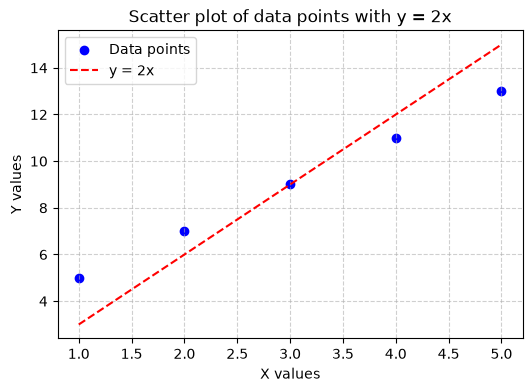

In [15]:
from matplotlib import pyplot as plt

%matplotlib inline

def plot_data(x, y):
    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, color='blue', label='Data points')
    x_line = np.linspace(min(x), max(x), 100)
    plt.plot(x_line, 3 * x_line, color='red', linestyle='--', label='y = 2x')
    plt.xlabel('X values')
    plt.ylabel('Y values')
    plt.title('Scatter plot of data points with y = 2x')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_data(x, y)

Now our aim is to derive an equation that best fit line for these data points.

### Mean Squared Error
This is a cost funtion that we use to reduce the error between each actual point (y) and predicted point ($y_{\text{predicted}}$)

Mathematically, the formula is represented as:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - y_{\text{predicted}, i})^2$$

In a simple linear regression model, the predicted value is calculated using the straight-line equation  $y_{\text{predicted}} = mx + b$ 

Substituting this in gives the full cost function equation:$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - (mx_i + b))^2$$



In [18]:


def gradient_descent(x, y, learning_rate=0.08, num_iterations=1000):
    m = 0  # initial slope
    b = 0  # initial intercept
    n = len(x)  # number of data points

    for _ in range(num_iterations):
        y_pred = m * x + b  # predicted values
        error = y - y_pred  # error

        cost = (1/n) * np.sum(error ** 2)  # mean squared error

        # Calculate gradients
        m_gradient = -(2/n) * np.sum(x * error)
        b_gradient = -(2/n) * np.sum(error)

        # Update parameters
        m -= learning_rate * m_gradient
        b -= learning_rate * b_gradient
        print(f"Iteration {_+1}: m = {m:.4f}, b = {b:.4f}, cost = {cost:.4f}")

    return m, b


m, b = gradient_descent(x, y)

print(f"Optimal slope (m): {m}")
print(f"Optimal intercept (b): {b}")

Iteration 1: m = 4.9600, b = 1.4400, cost = 89.0000
Iteration 2: m = 0.4992, b = 0.2688, cost = 71.1056
Iteration 3: m = 4.4516, b = 1.4262, cost = 56.8298
Iteration 4: m = 0.8922, b = 0.5012, cost = 45.4397
Iteration 5: m = 4.0413, b = 1.4328, cost = 36.3509
Iteration 6: m = 1.2009, b = 0.7037, cost = 29.0975
Iteration 7: m = 3.7096, b = 1.4547, cost = 23.3079
Iteration 8: m = 1.4425, b = 0.8813, cost = 18.6858
Iteration 9: m = 3.4407, b = 1.4879, cost = 14.9949
Iteration 10: m = 1.6309, b = 1.0383, cost = 12.0468
Iteration 11: m = 3.2221, b = 1.5294, cost = 9.6913
Iteration 12: m = 1.7771, b = 1.1781, cost = 7.8085
Iteration 13: m = 3.0439, b = 1.5766, cost = 6.3029
Iteration 14: m = 1.8898, b = 1.3032, cost = 5.0983
Iteration 15: m = 2.8982, b = 1.6276, cost = 4.1340
Iteration 16: m = 1.9762, b = 1.4160, cost = 3.3613
Iteration 17: m = 2.7784, b = 1.6809, cost = 2.7418
Iteration 18: m = 2.0416, b = 1.5183, cost = 2.2445
Iteration 19: m = 2.6796, b = 1.7355, cost = 1.8449
Iteration 2